#### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Dataset Loading

#### Dataset First View

In [25]:
data = pd.read_csv("E:\Data Analyst Coding\Machine Learning Project Internship\TSLA.csv")
data

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300


#### Dataset Rows & Columns count

In [3]:
rows, columns = data.shape
rows, columns

(2416, 7)

#### Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


#### Duplicate Values

#### Missing Values/Null Values

In [5]:
data.isna()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2411,False,False,False,False,False,False,False
2412,False,False,False,False,False,False,False
2413,False,False,False,False,False,False,False
2414,False,False,False,False,False,False,False


In [6]:
data.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

#### What did you know about your dataset?

#### 2. Understanding Your Variables

In [7]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [8]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


#### Variables Description

#### Check Unique Values for each variable

In [9]:
for i in data.columns:
    print("Unique Values:", data[i].nunique())

Unique Values: 2416
Unique Values: 2132
Unique Values: 2128
Unique Values: 2136
Unique Values: 2225
Unique Values: 2225
Unique Values: 2391


#### Date-Based Features

In [31]:
data['Date'] = pd.to_datetime(data['Date'], errors = 'coerce')    # Convert Date Column
data['Date']

0      2010-06-29
1      2010-06-30
2      2010-07-01
3      2010-07-02
4      2010-07-06
          ...    
2411   2020-01-28
2412   2020-01-29
2413   2020-01-30
2414   2020-01-31
2415   2020-02-03
Name: Date, Length: 2416, dtype: datetime64[ns]

In [32]:
data['Year'] = data['Date'].dt.year
data['Year']

0       2010
1       2010
2       2010
3       2010
4       2010
        ... 
2411    2020
2412    2020
2413    2020
2414    2020
2415    2020
Name: Year, Length: 2416, dtype: int32

In [33]:
data['Month'] =  data['Date'].dt.month
data['Month']

0       6
1       6
2       7
3       7
4       7
       ..
2411    1
2412    1
2413    1
2414    1
2415    2
Name: Month, Length: 2416, dtype: int32

In [34]:
data['Day'] = data['Date'].dt.day
data['Day']

0       29
1       30
2        1
3        2
4        6
        ..
2411    28
2412    29
2413    30
2414    31
2415     3
Name: Day, Length: 2416, dtype: int32

In [35]:
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['DayOfWeek']

0       1
1       2
2       3
3       4
4       1
       ..
2411    1
2412    2
2413    3
2414    4
2415    0
Name: DayOfWeek, Length: 2416, dtype: int32

In [36]:
data['Quarter'] = data['Date'].dt.quarter
data['Quarter']

0       2
1       2
2       3
3       3
4       3
       ..
2411    1
2412    1
2413    1
2414    1
2415    1
Name: Quarter, Length: 2416, dtype: int32

#### Daily Price Change

In [16]:
data['Price_Change'] = data['Close'] - data['Open']
data['Price_Change']

0         4.889999
1        -1.960001
2        -3.040001
3        -3.799999
4        -3.889999
           ...    
2411     -1.589966
2412      5.299988
2413      8.390015
2414     10.570007
2415    106.309998
Name: Price_Change, Length: 2416, dtype: float64

#### Daily Return

In [17]:
data['Daily_Return'] = data['Adj Close'].pct_change()
data['Daily_Return']

0            NaN
1      -0.002511
2      -0.078473
3      -0.125683
4      -0.160937
          ...   
2411    0.015913
2412    0.024854
2413    0.102962
2414    0.015231
2415    0.198949
Name: Daily_Return, Length: 2416, dtype: float64

#### High-Low Spread (Volatility)

In [18]:
data['High_Low_Spread'] = data['High'] - data['Low']
data['High_Low_Spread']

0         7.459999
1         7.120001
2         5.650000
3         4.390001
4         4.170000
           ...    
2411     18.729981
2412     22.369995
2413     32.880005
2414     20.479980
2415    112.619995
Name: High_Low_Spread, Length: 2416, dtype: float64

#### Open-Close Spread

In [19]:
data['Open_Close_Spread'] = data['Open'] - data['Close']
data['Open_Close_Spread']

0        -4.889999
1         1.960001
2         3.040001
3         3.799999
4         3.889999
           ...    
2411      1.589966
2412     -5.299988
2413     -8.390015
2414    -10.570007
2415   -106.309998
Name: Open_Close_Spread, Length: 2416, dtype: float64

#### Moving Averages

In [20]:
data['MA7'] = data['Adj Close'].rolling(window=7).mean()        # 7-Day Moving Average
data['MA7']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2411    555.600010
2412    565.670009
2413    579.042864
2414    590.615723
2415    620.301435
Name: MA7, Length: 2416, dtype: float64

In [21]:
data['MA30'] = data['Adj Close'].rolling(window=30).mean()       # 30-Day Moving Average
data['MA30']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2411    469.665002
2412    477.085002
2413    485.728668
2414    494.781335
2415    507.676336
Name: MA30, Length: 2416, dtype: float64

#### Exponential Moving Average (EMA)

In [22]:
data['EMA20'] = data['Adj Close'].ewm(span=20).mean()
data['EMA20']

0        23.889999
1        23.858500
2        23.161382
3        22.017792
4        20.588748
           ...    
2411    509.216688
2412    516.052241
2413    527.933932
2414    539.613558
2415    562.507505
Name: EMA20, Length: 2416, dtype: float64

#### Rolling Standard Deviation

In [23]:
data['Volatility_7'] = data['Adj Close'].rolling(7).std()
data['Volatility_7']

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
2411    21.577640
2412    10.757736
2413    28.128923
2414    38.375573
2415    79.785842
Name: Volatility_7, Length: 2416, dtype: float64

#### Volume Change

In [24]:
data['Volume_Change'] = data['Volume'].pct_change()
data['Volume_Change']

0            NaN
1      -0.084151
2      -0.521804
3      -0.374629
4       0.336025
          ...   
2411   -0.133714
2412    0.510073
2413    0.629396
2414   -0.458062
2415    1.994090
Name: Volume_Change, Length: 2416, dtype: float64

#### Lag Features (LSTM)

In [25]:
data['Lag_1'] = data['Adj Close'].shift(1)
data['Lag_1']

0              NaN
1        23.889999
2        23.830000
3        21.959999
4        19.200001
           ...    
2411    558.020020
2412    566.900024
2413    580.989990
2414    640.809998
2415    650.570007
Name: Lag_1, Length: 2416, dtype: float64

In [26]:
data['Lag_2'] = data['Adj Close'].shift(2)
data['Lag_2']

0              NaN
1              NaN
2        23.889999
3        23.830000
4        21.959999
           ...    
2411    564.820007
2412    558.020020
2413    566.900024
2414    580.989990
2415    640.809998
Name: Lag_2, Length: 2416, dtype: float64

In [27]:
data['Lag_3'] = data['Adj Close'].shift(3)
data['Lag_3']

0              NaN
1              NaN
2              NaN
3        23.889999
4        23.830000
           ...    
2411    572.200012
2412    564.820007
2413    558.020020
2414    566.900024
2415    580.989990
Name: Lag_3, Length: 2416, dtype: float64

In [28]:
data['Lag_5'] = data['Adj Close'].shift(5)
data['Lag_5']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2411    547.200012
2412    569.559998
2413    572.200012
2414    564.820007
2415    558.020020
Name: Lag_5, Length: 2416, dtype: float64

#### Rolling Maximum and Minimum

In [14]:
data['Rolling_Max_7'] = data['Adj Close'].rolling(7).max()
data['Rolling_Max_7']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2411    572.200012
2412    580.989990
2413    640.809998
2414    650.570007
2415    780.000000
Name: Rolling_Max_7, Length: 2416, dtype: float64

In [30]:
data['Rolling_Min_7'] = data['Adj Close'].rolling(7).min()
data['Rolling_Min_7']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2411    510.500000
2412    547.200012
2413    558.020020
2414    558.020020
2415    558.020020
Name: Rolling_Min_7, Length: 2416, dtype: float64

# Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

#### Stock Price Trend Over Time

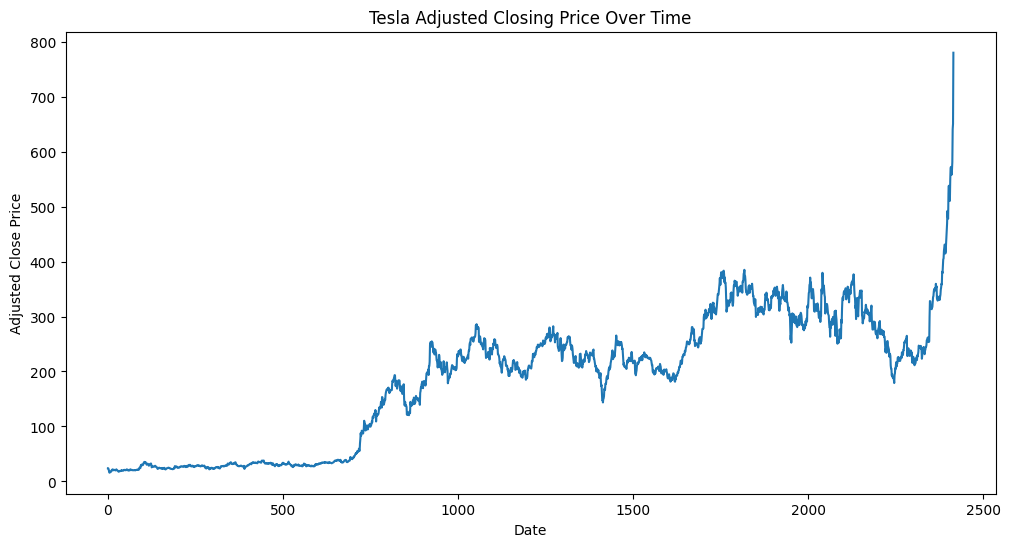

In [9]:
plt.figure(figsize = (12,6))
plt.plot(data['Adj Close'])
plt.title('Tesla Adjusted Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.show()

#### Trading Volume Trend

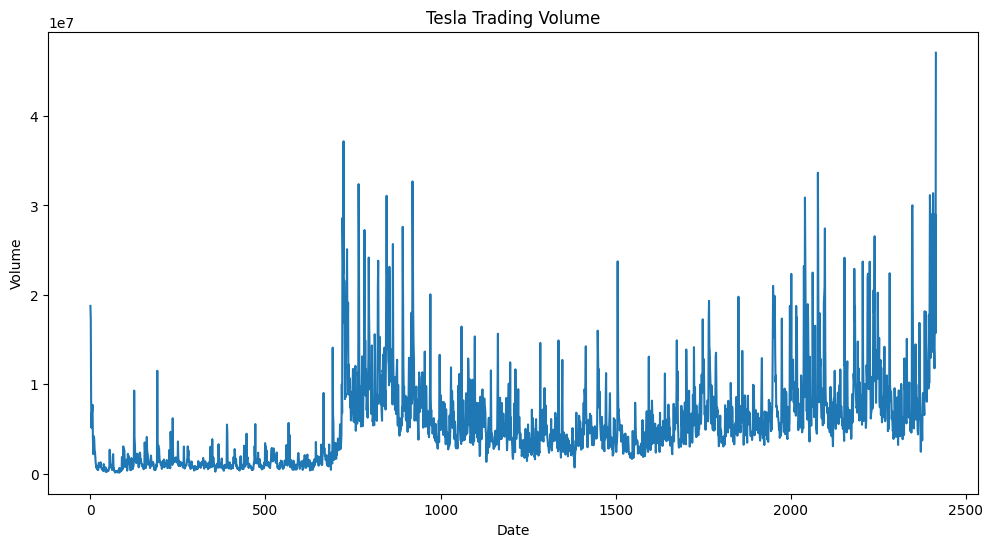

In [10]:
plt.figure(figsize = (12,6))
plt.plot(data['Volume'])
plt.title('Tesla Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

#### Histogram Plot Represents Distribution Stock Prices

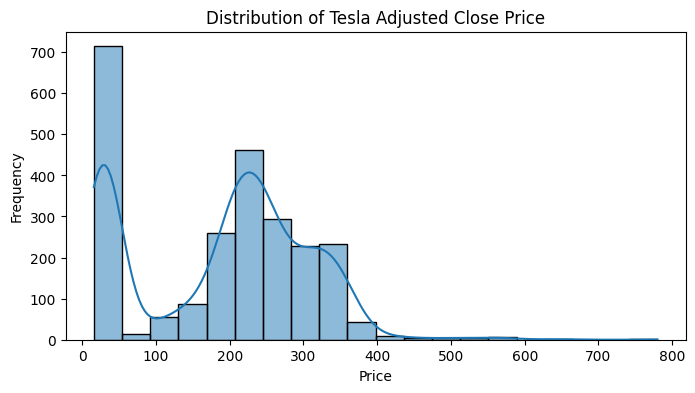

In [12]:
plt.figure(figsize = (8,4))
sns.histplot(data['Adj Close'], bins = 20, kde = True)
plt.title('Distribution of Tesla Adjusted Close Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

#### Scatter Plot Represents Open vs Close Relationship

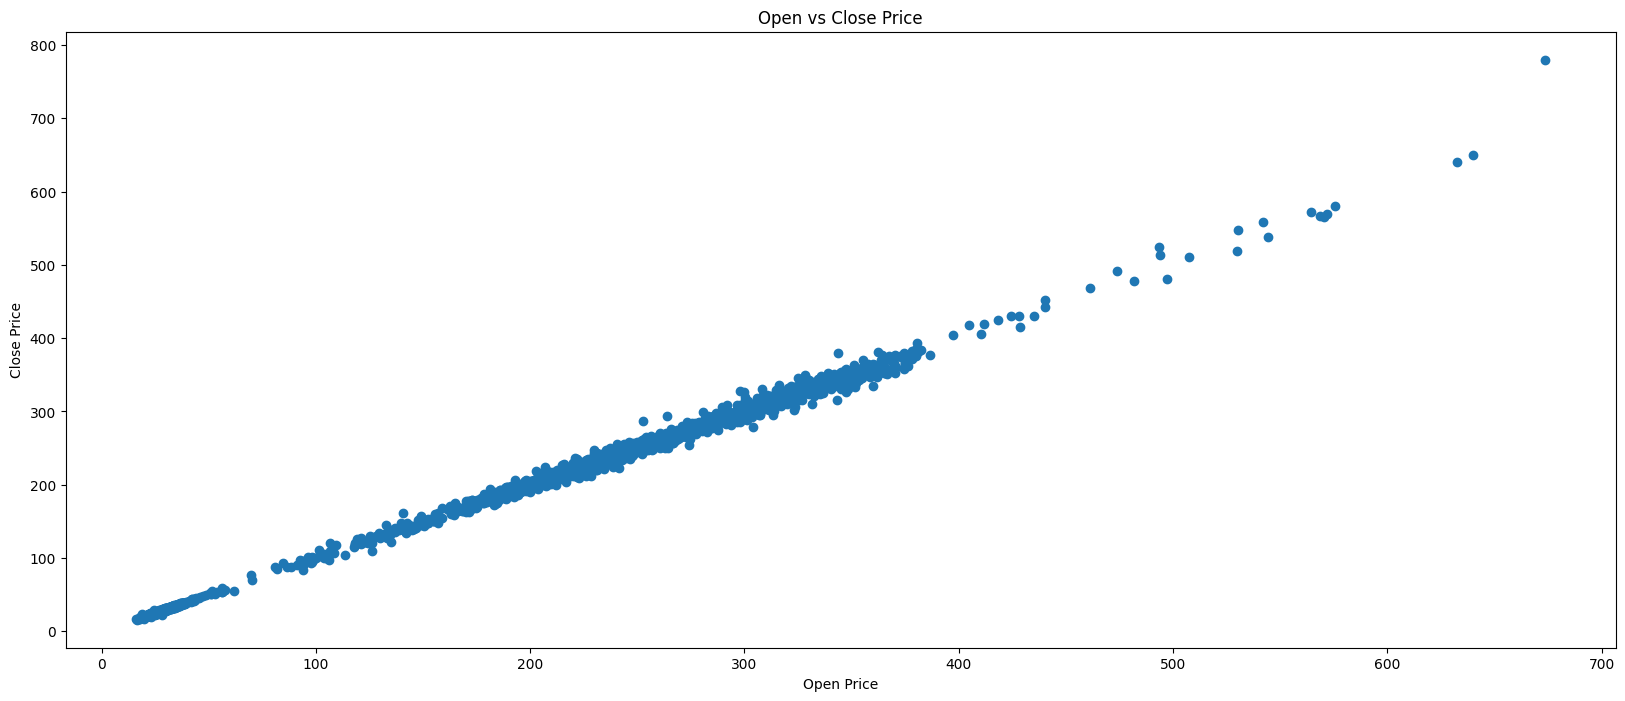

In [19]:
plt.figure(figsize=(20,8))
plt.scatter(data['Open'], data['Close'])
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.title('Open vs Close Price')
plt.show()

#### Correlation Heatmap

In [30]:
numeric_data = data.select_dtypes(include = np.number)
numeric_data

,Open,High,Low,Close,Adj Close,Volume
0,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...
2411,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,640.000000,653.000000,632.520020,650.570007,650.570007,15719300


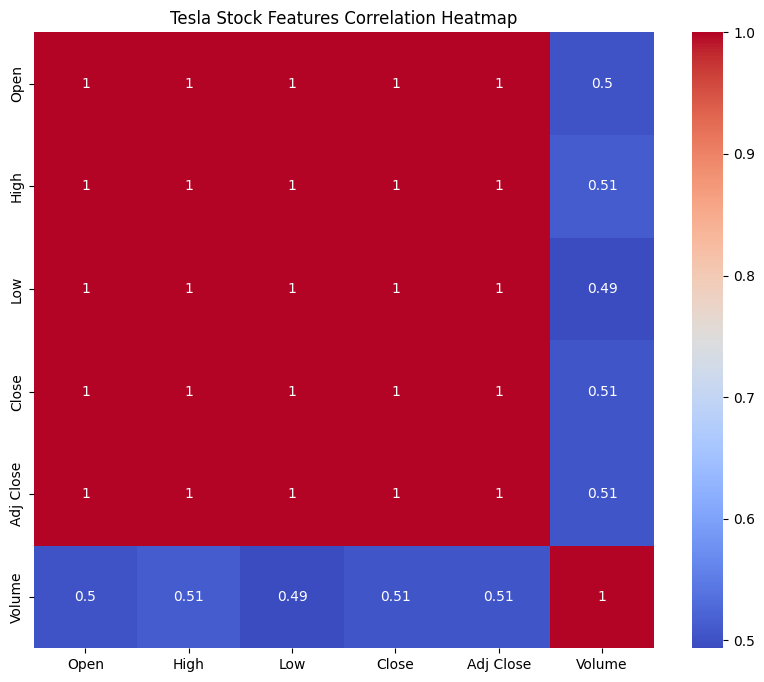

In [31]:
plt.figure(figsize = (10,8))
sns.heatmap(numeric_data.corr(), annot = True, cmap = 'coolwarm')
plt.title("Tesla Stock Features Correlation Heatmap")
plt.show()

#### Histogram Plots Represents Daily Returns Analysis

In [32]:
data['Daily_Return'] = data['Adj Close'].pct_change()
data['Daily_Return']

0            NaN
1      -0.002511
2      -0.078473
3      -0.125683
4      -0.160937
          ...   
2411    0.015913
2412    0.024854
2413    0.102962
2414    0.015231
2415    0.198949
Name: Daily_Return, Length: 2416, dtype: float64

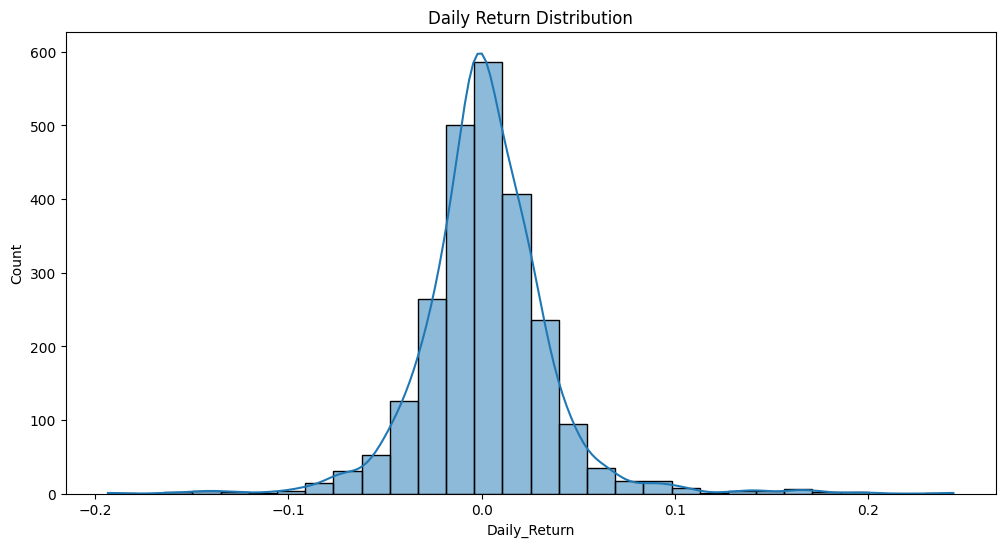

In [34]:
plt.figure(figsize=(12,6))
sns.histplot(data['Daily_Return'].dropna(), bins = 30, kde = True)
plt.title('Daily Return Distribution')
plt.show()

#### Boxplot for Outlier Detection

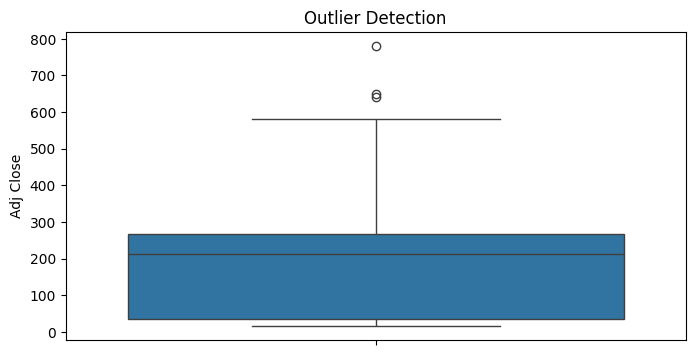

In [37]:
plt.figure(figsize = (8,4))
sns.boxplot(y = data['Adj Close'])
plt.title('Outlier Detection')
plt.show()

#### High-Low Price Spread (Volatility)

In [38]:
data['Daily_Range'] = data['High'] - data['Low']
data['Daily_Range']

0         7.459999
1         7.120001
2         5.650000
3         4.390001
4         4.170000
           ...    
2411     18.729981
2412     22.369995
2413     32.880005
2414     20.479980
2415    112.619995
Name: Daily_Range, Length: 2416, dtype: float64

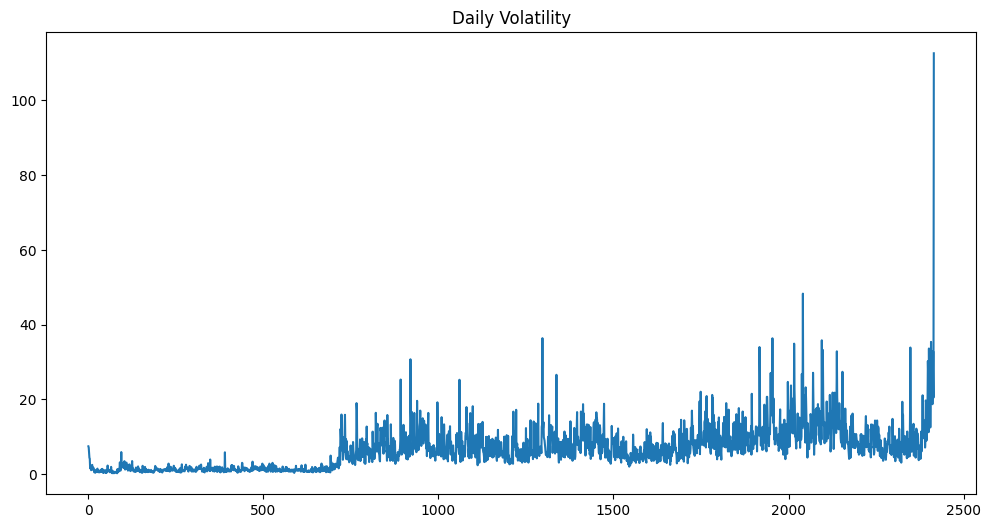

In [39]:
plt.figure(figsize = (12,6))
plt.plot(data['Daily_Range'])
plt.title('Daily Volatility')
plt.show()

#### Moving Average Trend Analysis

#### 7-Day and 30-Day Moving Averages

In [41]:
data['MA7'] = data['Adj Close'].rolling(7).mean()
data['MA7']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2411    555.600010
2412    565.670009
2413    579.042864
2414    590.615723
2415    620.301435
Name: MA7, Length: 2416, dtype: float64

In [42]:
data['MA30'] = data['Adj Close'].rolling(30).mean()
data['MA30']

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
2411    469.665002
2412    477.085002
2413    485.728668
2414    494.781335
2415    507.676336
Name: MA30, Length: 2416, dtype: float64

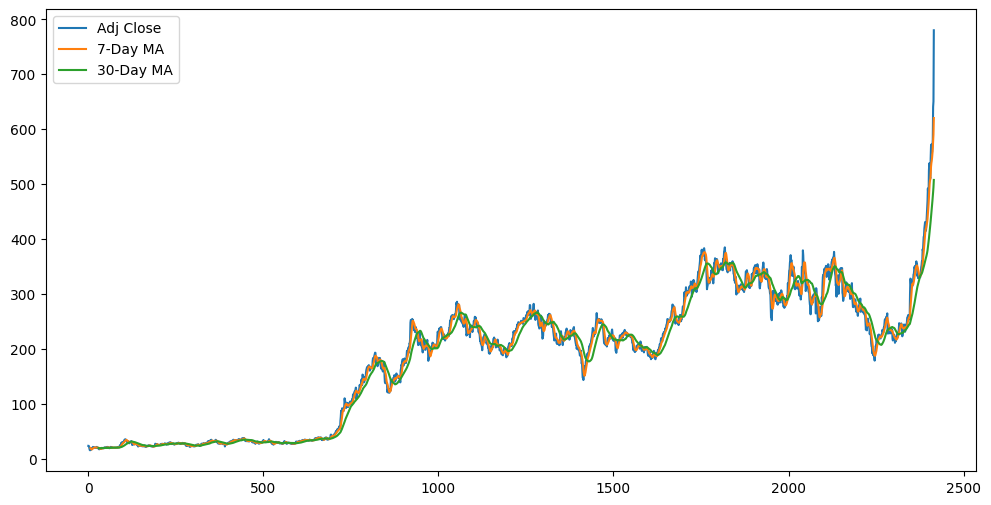

In [43]:
plt.figure(figsize = (12,6))
plt.plot(data['Adj Close'], label='Adj Close')
plt.plot(data['MA7'], label='7-Day MA')
plt.plot(data['MA30'], label='30-Day MA')
plt.legend()
plt.show()

#### Scaling the Data using MinMaxScaler

In [44]:
from sklearn.preprocessing import MinMaxScaler

In [46]:
features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']          # Select Features
data = data[features]

In [47]:
target = data['Adj Close']

In [48]:
scaler = MinMaxScaler(feature_range = (0,1))              # Apply MinMaxScaler

scaled_data = scaler.fit_transform(data)
scaled_data

array([[0.00434948, 0.01087705, 0.00388739, 0.01058623, 0.01058623,
        0.39721385],
       [0.01467569, 0.0179205 , 0.01263401, 0.01050772, 0.01050772,
        0.36357556],
       [0.01347426, 0.01207262, 0.00803292, 0.00806072, 0.00806072,
        0.17254321],
       ...,
       [0.93723668, 0.8242258 , 0.91569226, 0.81786181, 0.81786181,
        0.6153217 ],
       [0.94876435, 0.82698079, 0.93774107, 0.83063335, 0.83063335,
        0.33231018],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ]], shape=(2416, 6))

In [49]:
print(scaled_data[:5])                       # Verify Scaling

[[0.00434948 0.01087705 0.00388739 0.01058623 0.01058623 0.39721385]
 [0.01467569 0.0179205  0.01263401 0.01050772 0.01050772 0.36357556]
 [0.01347426 0.01207262 0.00803292 0.00806072 0.00806072 0.17254321]
 [0.01043267 0.00840795 0.00566404 0.0044491  0.0044491  0.10695792]
 [0.00587028 0.00437941 0.00129073 0.00040565 0.00040565 0.14374661]]


#### Creating Time-Series Sequences

In [52]:
window_size = 60

X = []
y = []

for i in range(window_size, len(scaled_data)):
    
    X.append(scaled_data[i-window_size:i])

    y.append(scaled_data[i, 4])                            # Adj Close column index

X = np.array(X)
X

array([[[4.34948063e-03, 1.08770527e-02, 3.88738865e-03, 1.05862327e-02,
         1.05862327e-02, 3.97213850e-01],
        [1.46756930e-02, 1.79204958e-02, 1.26340067e-02, 1.05077205e-02,
         1.05077205e-02, 3.63575559e-01],
        [1.34742620e-02, 1.20726187e-02, 8.03292107e-03, 8.06071578e-03,
         8.06071578e-03, 1.72543214e-01],
        ...,
        [6.88921144e-03, 6.13377461e-03, 7.86588490e-03, 6.88301361e-03,
         6.88301361e-03, 1.76583984e-02],
        [7.22378523e-03, 6.39367896e-03, 8.64032531e-03, 6.50353311e-03,
         6.50353311e-03, 1.44313208e-02],
        [7.19337233e-03, 5.61396461e-03, 7.31921957e-03, 5.32583224e-03,
         5.32583224e-03, 1.79864314e-02]],

       [[1.46756930e-02, 1.79204958e-02, 1.26340067e-02, 1.05077205e-02,
         1.05077205e-02, 3.63575559e-01],
        [1.34742620e-02, 1.20726187e-02, 8.03292107e-03, 8.06071578e-03,
         8.06071578e-03, 1.72543214e-01],
        [1.04326682e-02, 8.40794904e-03, 5.66404301e-03, 4.449098

In [53]:
y = np.array(y)
y

array([0.00492018, 0.0056268 , 0.00618948, ..., 0.81786181, 0.83063335,
       1.        ], shape=(2356,))

In [54]:
print(X.shape)                             # Check Shapes

(2356, 60, 6)


In [55]:
print(y.shape)

(2356,)


#### Train-Test Split

In [56]:
train_size = int(len(X) * 0.8)                # For time-series data, so did not randomly shuffle

X_train = X[:train_size]
X_train



array([[[4.34948063e-03, 1.08770527e-02, 3.88738865e-03, 1.05862327e-02,
         1.05862327e-02, 3.97213850e-01],
        [1.46756930e-02, 1.79204958e-02, 1.26340067e-02, 1.05077205e-02,
         1.05077205e-02, 3.63575559e-01],
        [1.34742620e-02, 1.20726187e-02, 8.03292107e-03, 8.06071578e-03,
         8.06071578e-03, 1.72543214e-01],
        ...,
        [6.88921144e-03, 6.13377461e-03, 7.86588490e-03, 6.88301361e-03,
         6.88301361e-03, 1.76583984e-02],
        [7.22378523e-03, 6.39367896e-03, 8.64032531e-03, 6.50353311e-03,
         6.50353311e-03, 1.44313208e-02],
        [7.19337233e-03, 5.61396461e-03, 7.31921957e-03, 5.32583224e-03,
         5.32583224e-03, 1.79864314e-02]],

       [[1.46756930e-02, 1.79204958e-02, 1.26340067e-02, 1.05077205e-02,
         1.05077205e-02, 3.63575559e-01],
        [1.34742620e-02, 1.20726187e-02, 8.03292107e-03, 8.06071578e-03,
         8.06071578e-03, 1.72543214e-01],
        [1.04326682e-02, 8.40794904e-03, 5.66404301e-03, 4.449098

In [57]:
X_test = X[train_size:]
X_test

array([[[0.48140826, 0.41126171, 0.47082941, 0.4098142 , 0.4098142 ,
         0.12429681],
        [0.47669378, 0.41209339, 0.47412455, 0.41332113, 0.41332113,
         0.0908843 ],
        [0.47657214, 0.40842875, 0.47049533, 0.40486785, 0.40486785,
         0.08727594],
        ...,
        [0.47637443, 0.41093683, 0.46484647, 0.40539127, 0.40539127,
         0.13731162],
        [0.46656527, 0.40385439, 0.4617639 , 0.3998299 , 0.3998299 ,
         0.12777949],
        [0.45678656, 0.39521253, 0.44748991, 0.38963622, 0.38963622,
         0.15689775]],

       [[0.47669378, 0.41209339, 0.47412455, 0.41332113, 0.41332113,
         0.0908843 ],
        [0.47657214, 0.40842875, 0.47049533, 0.40486785, 0.40486785,
         0.08727594],
        [0.46793398, 0.39935803, 0.45798278, 0.39451715, 0.39451715,
         0.09073946],
        ...,
        [0.46656527, 0.40385439, 0.4617639 , 0.3998299 , 0.3998299 ,
         0.12777949],
        [0.45678656, 0.39521253, 0.44748991, 0.38963622, 0.389

In [58]:
y_train = y[:train_size]
y_train

array([0.00492018, 0.0056268 , 0.00618948, ..., 0.40539127, 0.3998299 ,
       0.38963622], shape=(1884,))

In [59]:
y_test = y[train_size:]
y_test

array([0.38569745, 0.39352264, 0.38380006, 0.37390737, 0.37736194,
       0.34464799, 0.31664486, 0.32757132, 0.30970949, 0.3294033 ,
       0.35480241, 0.37937713, 0.37097617, 0.35836169, 0.37804241,
       0.37310912, 0.36414549, 0.37233708, 0.36038994, 0.35578383,
       0.36319027, 0.37199684, 0.35912064, 0.35013085, 0.35024861,
       0.34662392, 0.35289193, 0.36414549, 0.36390996, 0.37178751,
       0.37339701, 0.35154411, 0.36415859, 0.37551687, 0.37447004,
       0.3808558 , 0.37846112, 0.37327924, 0.36138446, 0.35119078,
       0.35420049, 0.35166188, 0.34155981, 0.35159643, 0.33919132,
       0.34450407, 0.34290762, 0.34421618, 0.35064121, 0.36105732,
       0.35191051, 0.36118818, 0.36762626, 0.36028527, 0.39740906,
       0.39294687, 0.39500131, 0.41389689, 0.42785918, 0.4304894 ,
       0.44742214, 0.44801101, 0.46457732, 0.44065688, 0.45331065,
       0.43406178, 0.41589899, 0.41508769, 0.42685161, 0.430123  ,
       0.43722847, 0.42809476, 0.41778331, 0.38610309, 0.38387

In [60]:
print(X_train.shape)                 # Verify LSTM Input Shape

(1884, 60, 6)


# Model Development

#### Define SimpleRNN Architecture

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [63]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(units = 50, activation ='tanh', input_shape = (X_train.shape[1], X_train.shape[2])))

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

rnn_model.summary()

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,901 (11.33 KB)

 Trainable params: 2,901 (11.33 KB)

 Non-trainable params: 0 (0.00 B)

#### Define LSTM Architecture

In [64]:
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [65]:
lstm_model = Sequential()

lstm_model.add(LSTM(units = 50, activation = 'tanh', input_shape = (X_train.shape[1], X_train.shape[2])))

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          11,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,451 (44.73 KB)

 Trainable params: 11,451 (44.73 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model

In [66]:
rnn_model.compile(optimizer = 'adam', loss = 'mean_squared_error')         # Using Adam Optimizer

lstm_model.compile(optimizer = 'adam', loss = 'mean_squared_error')

In [67]:
from tensorflow.keras.optimizers import SGD                 # Alternative: SGD Optimizer

sgd = SGD(learning_rate = 0.01)

lstm_model.compile(optimizer = sgd, loss = 'mean_squared_error')

#### Model Training

In [68]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [69]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)
early_stop

In [70]:
checkpoint = ModelCheckpoint('best_lstm_model.keras', monitor = 'val_loss', save_best_only = True, verbose = 1)
checkpoint

#### Train SimpleRNN

In [71]:
rnn_history = rnn_model.fit(X_train, y_train, epochs = 100, batch_size = 32, validation_data = (X_test, y_test),
    callbacks=[early_stop, checkpoint]
)
rnn_history

Epoch 1/100
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0446
Epoch 1: val_loss improved from None to 0.00175, saving model to best_lstm_model.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0190 - val_loss: 0.0017
Epoch 2/100
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0043
Epoch 2: val_loss improved from 0.00175 to 0.00129, saving model to best_lstm_model.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0037 - val_loss: 0.0013
Epoch 3/100
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0026
Epoch 3: val_loss improved from 0.00129 to 0.00100, saving model to best_lstm_model.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0023 - val_loss: 0.0010
Epoch 4/100
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0019
Epoch 4: val_loss did not improve from 0.00100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0017
Epoch 5: val_loss improved from 0.00100 to 0.00086, sav

#### Train LSTM

In [72]:
lstm_history = lstm_model.fit(X_train, y_train, epochs = 100, batch_size = 32, validation_data = (X_test, y_test),
    callbacks=[early_stop, checkpoint])
lstm_history

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0056
Epoch 1: val_loss did not improve from 0.00029
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0046 - val_loss: 0.0047
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0037
Epoch 2: val_loss did not improve from 0.00029
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 3/100
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0030
Epoch 3: val_loss did not improve from 0.00029
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0029 - val_loss: 0.0031
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0027
Epoch 4: val_loss did not improve from 0.00029
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 5/100
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0028
Epoch 5: val_loss did not improve from 0.00029
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 6/100
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 

# Model Evaluation & Prediction

#### Predict Tesla Stock Prices

In [73]:
predictions = lstm_model.predict(X_test)
predictions

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step


array([[0.36045915],
       [0.35799554],
       [0.35721985],
       [0.35538277],
       [0.35302773],
       [0.35075644],
       [0.34482735],
       [0.33477506],
       [0.32614642],
       [0.31845298],
       [0.31405947],
       [0.311844  ],
       [0.31267563],
       [0.3138059 ],
       [0.3158986 ],
       [0.32058713],
       [0.32408875],
       [0.32712767],
       [0.33042562],
       [0.33185676],
       [0.33245444],
       [0.33339387],
       [0.33484948],
       [0.3347826 ],
       [0.33391017],
       [0.33303577],
       [0.33163887],
       [0.33118537],
       [0.3317434 ],
       [0.3321759 ],
       [0.33329454],
       [0.3339815 ],
       [0.33032694],
       [0.32759255],
       [0.32871523],
       [0.32994595],
       [0.33239323],
       [0.33448067],
       [0.3359138 ],
       [0.33594716],
       [0.3337617 ],
       [0.33198267],
       [0.3311706 ],
       [0.32951325],
       [0.32826415],
       [0.32562009],
       [0.32402715],
       [0.323

In [81]:
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(
    data[['Open','High','Low','Close','Adj Close','Volume']]
)
X_scaled

array([[0.00434948, 0.01087705, 0.00388739, 0.01058623, 0.01058623,
        0.39721385],
       [0.01467569, 0.0179205 , 0.01263401, 0.01050772, 0.01050772,
        0.36357556],
       [0.01347426, 0.01207262, 0.00803292, 0.00806072, 0.00806072,
        0.17254321],
       ...,
       [0.93723668, 0.8242258 , 0.91569226, 0.81786181, 0.81786181,
        0.6153217 ],
       [0.94876435, 0.82698079, 0.93774107, 0.83063335, 0.83063335,
        0.33231018],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        ]], shape=(2416, 6))

In [82]:
target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(data[['Adj Close']])
y_scaled

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       ...,
       [0.81786181],
       [0.83063335],
       [1.        ]], shape=(2416, 1))

In [83]:
predictions = lstm_model.predict(X_test)
predictions

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


array([[0.36045915],
       [0.35799554],
       [0.35721985],
       [0.35538277],
       [0.35302773],
       [0.35075644],
       [0.34482735],
       [0.33477506],
       [0.32614642],
       [0.31845298],
       [0.31405947],
       [0.311844  ],
       [0.31267563],
       [0.3138059 ],
       [0.3158986 ],
       [0.32058713],
       [0.32408875],
       [0.32712767],
       [0.33042562],
       [0.33185676],
       [0.33245444],
       [0.33339387],
       [0.33484948],
       [0.3347826 ],
       [0.33391017],
       [0.33303577],
       [0.33163887],
       [0.33118537],
       [0.3317434 ],
       [0.3321759 ],
       [0.33329454],
       [0.3339815 ],
       [0.33032694],
       [0.32759255],
       [0.32871523],
       [0.32994595],
       [0.33239323],
       [0.33448067],
       [0.3359138 ],
       [0.33594716],
       [0.3337617 ],
       [0.33198267],
       [0.3311706 ],
       [0.32951325],
       [0.32826415],
       [0.32562009],
       [0.32402715],
       [0.323

In [84]:
predictions_actual = target_scaler.inverse_transform(predictions)

y_test_actual = target_scaler.inverse_transform(
    y_test.reshape(-1,1)
)
y_test_actual

array([[310.549988],
       [316.529999],
       [309.100006],
       [301.540009],
       [304.179993],
       [279.179993],
       [257.779999],
       [266.130005],
       [252.479996],
       [267.529999],
       [286.940002],
       [305.720001],
       [299.299988],
       [289.660004],
       [304.700012],
       [300.929993],
       [294.079987],
       [300.339996],
       [291.209991],
       [287.690002],
       [293.350006],
       [300.079987],
       [290.23999 ],
       [283.369995],
       [283.459991],
       [280.690002],
       [285.480011],
       [294.079987],
       [293.899994],
       [299.920013],
       [301.149994],
       [284.450012],
       [294.089996],
       [302.769989],
       [301.970001],
       [306.850006],
       [305.019989],
       [301.059998],
       [291.970001],
       [284.179993],
       [286.480011],
       [284.540009],
       [276.820007],
       [284.48999 ],
       [275.01001 ],
       [279.070007],
       [277.850006],
       [278.8

#### Compare Actual vs Predicted Prices

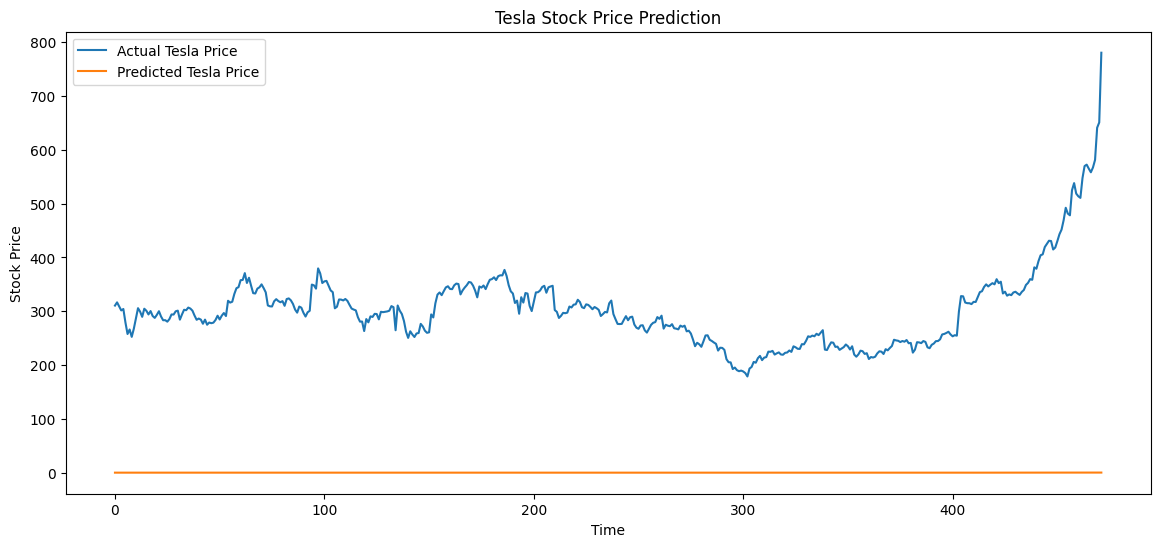

In [79]:
plt.figure(figsize = (14,6))
plt.plot(y_test_actual, label='Actual Tesla Price')
plt.plot(predictions, label = 'Predicted Tesla Price')
plt.title('Tesla Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

#### Calculate Mean Squared Error (MSE)

In [80]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test_actual,
    predictions
)

print("MSE:", mse)

MSE: 96434.87470999503
